In [1]:
!python -m textblob.download_corpora

zsh:1: command not found: python


In [2]:
!pip install gensim


zsh:1: command not found: pip


In [ ]:
!pip install -q nrclex

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.4/396.4 kB 19.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
!pip install numpy==1.26.4

In [ ]:
pip install --upgrade pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 109.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.


In [3]:
import warnings
from nrclex import NRCLex
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
#Importing necessary libraries
import gensim
import gensim.corpora as corpora
nltk.download('stopwords')
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kishankunal/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
from textblob import TextBlob
import spacy

In [5]:
text = "The service was outstanding and the food was delicious!"


In [ ]:
# Step 2: Create a TextBlob object
blob = TextBlob(text)

# Step 3: Extract sentiment
sentiment = blob.sentiment

In [ ]:
print("Polarity:", sentiment.polarity)
print("Subjectivity:", sentiment.subjectivity)

Polarity: 0.75
Subjectivity: 0.9375


In [ ]:
from textblob import TextBlob

text = "The movie was a masterpiece, but too long and slightly boring in parts."
blob = TextBlob(text)
print("Polarity:", blob.sentiment.polarity)
print("Subjectivity:", blob.sentiment.subjectivity)

Polarity: -0.525
Subjectivity: 0.7


In [7]:
text2 = "The sun is 93 million miles away from Earth."
blob2 = TextBlob(text2)
print("Polarity:", blob2.sentiment.polarity)
print("Subjectivity:", blob2.sentiment.subjectivity)

Polarity: 0.0
Subjectivity: 0.0


In [9]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy
#Reading training, test and sample data files
training= pd.read_csv('train.csv')

training.head()

,ID,Place,location,date,status,job_title,summary,positives,negatives,advice_to_mgmt,score_1,score_2,score_3,score_4,score_5,score_6,overall
0,1,startup_1,NaN,"Dec 11, 2018",Current Employee,Anonymous Employee,Best Company to work for,People are smart and friendly,Bureaucracy is slowing things down,NaN,4.0,5.0,5.0,4.0,5.0,0,5
1,2,startup_1,"Mountain View, CA","Jun 21, 2013",Former Employee,Program Manager,"Moving at the speed of light, burn out is inev...","1) Food, food, food. 15+ cafes on main campus ...",1) Work/life balance. What balance? All those ...,1) Don't dismiss emotional intelligence and ad...,2.0,3.0,3.0,5.0,3.0,2094,5
2,3,startup_1,"New York, NY","May 10, 2014",Current Employee,Software Engineer III,Great balance between big-company security and...,"* If you're a software engineer, you're among ...","* It *is* becoming larger, and with it comes g...",Keep the focus on the user. Everything else wi...,5.0,4.0,5.0,5.0,4.0,949,5
3,4,startup_1,"Mountain View, CA","Feb 8, 2015",Current Employee,Anonymous Employee,The best place I've worked and also the most d...,You can't find a more well-regarded company th...,I live in SF so the commute can take between 1...,Keep on NOT micromanaging - that is a huge ben...,2.0,5.0,5.0,4.0,5.0,498,4
4,10,startup_1,NaN,"Dec 9, 2018",Current Employee,Anonymous Employee,Execellent for engineers,Impact driven. Best tech in the world.,Size matters. Engineers are a bit disconnected...,NaN,5.0,5.0,5.0,5.0,5.0,0,4


In [10]:
print("Information of training dataset:\n", training.info())
#Creating set of negative and positive reviews from the training dataset
neg = training['negatives']
pos= training ['positives']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30336 entries, 0 to 30335
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              30336 non-null  int64  
 1   Place           30336 non-null  object 
 2   location        19082 non-null  object 
 3   date            30336 non-null  object 
 4   status          30336 non-null  object 
 5   job_title       30336 non-null  object 
 6   summary         30281 non-null  object 
 7   positives       30336 non-null  object 
 8   negatives       30336 non-null  object 
 9   advice_to_mgmt  16893 non-null  object 
 10  score_1         27150 non-null  float64
 11  score_2         24286 non-null  float64
 12  score_3         27167 non-null  float64
 13  score_4         27145 non-null  float64
 14  score_5         26851 non-null  float64
 15  score_6         30336 non-null  int64  
 16  overall         30336 non-null  int64  
dtypes: float64(5), int64(3), object

In [11]:
blob2 = TextBlob(pos.iloc[0])
print("Polarity:", blob2.sentiment.polarity)
print("Subjectivity:", blob2.sentiment.subjectivity)

Polarity: 0.29464285714285715
Subjectivity: 0.5714285714285714


In [12]:
blob2 = TextBlob(neg.iloc[0])
print("Polarity:", blob2.sentiment.polarity)
print("Subjectivity:", blob2.sentiment.subjectivity)

Polarity: -0.15555555555555559
Subjectivity: 0.2888888888888889


In [13]:
#Performing sentiment analysis on the negative reviews
slice_neg=neg [4:8,]
#Executing the for loop for displaying multiple reviews
for review in slice_neg:
  print('Review is:', review)
  print('Predicted Polarity:',TextBlob(review).sentiment.polarity)
  print('.'*50)

Review is: Size matters. Engineers are a bit disconnected with customers.
Predicted Polarity: 0.0
..................................................
Review is: There is lower compensation than expected
Predicted Polarity: -0.1
..................................................
Review is: Wide variety in experience based on team.
Predicted Polarity: -0.1
..................................................
Review is: Long hours, far locations, a lot of work
Predicted Polarity: 0.025
..................................................


In [ ]:
slice_pos=pos [14:18,]
for review in slice_pos:
  print('Review is:', review)
  print('Predicted Polarity:',TextBlob(review).sentiment.polarity)
  print('.'*50)

In [ ]:
# NRC Lexicon
!pip install -q nrclex

In [ ]:
from nrclex import NRCLex


# Define your input text
text = "I love the new phone design, but I'm scared about its durability."

# Create an NRCLex object
emotion = NRCLex(text)


In [ ]:
print("Raw Emotion Scores:", emotion.raw_emotion_scores)


In [ ]:
print("Top Emotions:", emotion.top_emotions)


In [14]:
emotion = NRCLex("I love this design but I fear it won't last long.")


In [15]:
emotion.raw_emotion_scores

{'joy': 1,
 'positive': 1,
 'anger': 1,
 'fear': 1,
 'negative': 1,
 'anticipation': 1}

In [16]:
emotion.raw_emotion_scores

{'joy': 1,
 'positive': 1,
 'anger': 1,
 'fear': 1,
 'negative': 1,
 'anticipation': 1}

In [17]:

text = "Although I am worried, I still trust the process and feel excited."

emotion = NRCLex(text)

In [18]:
print("Words in Lexicon:", emotion.words)
print("Raw Emotion Scores:", emotion.raw_emotion_scores)
print("Top Emotions:", emotion.top_emotions)
print("Emotion Frequencies:", emotion.affect_frequencies)

Words in Lexicon: ['Although', 'I', 'am', 'worried', 'I', 'still', 'trust', 'the', 'process', 'and', 'feel', 'excited']
Raw Emotion Scores: {'negative': 1, 'sadness': 1, 'trust': 2, 'anticipation': 1, 'joy': 1, 'positive': 1, 'surprise': 1}
Top Emotions: [('trust', 0.25)]
Emotion Frequencies: {'fear': 0.0, 'anger': 0.0, 'anticip': 0.0, 'trust': 0.25, 'surprise': 0.125, 'positive': 0.125, 'negative': 0.125, 'sadness': 0.125, 'disgust': 0.0, 'joy': 0.125, 'anticipation': 0.125}


In [19]:


# 📝 Define a sample sentence
text = "The movie made me happy, anxious and full of anticipation."

# 🧪 Step 1: Analyze text
emotion = NRCLex(text)

# 📤 Step 2: Get the raw emotion mapping
raw_dict = emotion.raw_emotion_scores

# 🧱 Step 3: Split the text into words
words = text.lower().split()

# 📦 Step 4: Create a DataFrame of words and their emotions
emotion_data = []

🔁 Pivot Table of Words vs Emotions:
Emotion        anticipation  fear  joy  negative  positive  trust
Word                                                             
anticipation.           1.0   0.0  0.0       0.0       0.0    0.0
anxious                 1.0   1.0  0.0       1.0       0.0    0.0
full                    0.0   0.0  0.0       0.0       1.0    0.0
happy,                  1.0   0.0  1.0       0.0       1.0    1.0


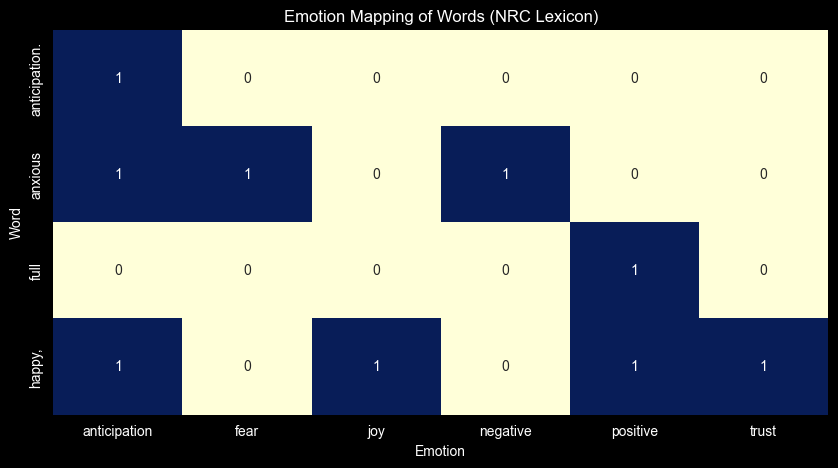

In [20]:

for word in words:
    word_emotion = NRCLex(word)
    for emo in word_emotion.raw_emotion_scores.keys():
        emotion_data.append({'Word': word, 'Emotion': emo, 'Flag': 1})

# Convert to DataFrame
df = pd.DataFrame(emotion_data)

# 🧊 Step 5: Create Pivot Table
pivot_table = pd.pivot_table(df, values='Flag', index='Word', columns='Emotion', fill_value=0)

# 🖨️ Display the Pivot Table
print("🔁 Pivot Table of Words vs Emotions:")
print(pivot_table)


plt.figure(figsize=(10, 5))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', cbar=False)
plt.title('Emotion Mapping of Words (NRC Lexicon)')
plt.show()

In [ ]:
#AFINN
!pip install -q afinn


In [21]:
# ✅ Import Afinn
from afinn import Afinn

# 🎯 Initialize Afinn
af = Afinn()

In [22]:
# 📝 Define input sentences
sentences = [
    "The service was amazing and the staff was wonderful!",
    "The food was horrible and I hated the experience.",
    "The hotel is okay, nothing special.",
    "Absolutely love this place!",
    "The customer support is terrible!"
]

In [23]:
# 🧪 Analyze each sentence
for sentence in sentences:
    score = af.score(sentence)
    print(f"'{sentence}' --> Sentiment Score: {score}")

'The service was amazing and the staff was wonderful!' --> Sentiment Score: 8.0
'The food was horrible and I hated the experience.' --> Sentiment Score: -6.0
'The hotel is okay, nothing special.' --> Sentiment Score: 0.0
'Absolutely love this place!' --> Sentiment Score: 3.0
'The customer support is terrible!' --> Sentiment Score: -1.0


In [24]:
afinn = Afinn()


In [25]:
for review in sentences:
    words = review.lower().split()  # split into words
    matched_words = [word for word in words if afinn.score(word) != 0]  # keep only known words
    word_scores = {word: afinn.score(word) for word in matched_words}  # get score for each

    total_score = afinn.score(review)  # total sentiment score

    print(f"\n📄 Review: {review}")
    print(f"🧩 Matched Words in AFINN: {matched_words}")
    print(f"📊 Word Scores: {word_scores}")
    print(f"✅ Total Review Score: {total_score}")


📄 Review: The service was amazing and the staff was wonderful!
🧩 Matched Words in AFINN: ['amazing', 'wonderful!']
📊 Word Scores: {'amazing': 4.0, 'wonderful!': 4.0}
✅ Total Review Score: 8.0

📄 Review: The food was horrible and I hated the experience.
🧩 Matched Words in AFINN: ['horrible', 'hated']
📊 Word Scores: {'horrible': -3.0, 'hated': -3.0}
✅ Total Review Score: -6.0

📄 Review: The hotel is okay, nothing special.
🧩 Matched Words in AFINN: []
📊 Word Scores: {}
✅ Total Review Score: 0.0

📄 Review: Absolutely love this place!
🧩 Matched Words in AFINN: ['love']
📊 Word Scores: {'love': 3.0}
✅ Total Review Score: 3.0

📄 Review: The customer support is terrible!
🧩 Matched Words in AFINN: ['support', 'terrible!']
📊 Word Scores: {'support': 2.0, 'terrible!': -3.0}
✅ Total Review Score: -1.0


In [26]:
from afinn import Afinn
#Displaying scores of negative reviews
neg_reviews_slice = neg[727:731,]
afinn= Afinn()
for review in neg_reviews_slice:
  print ("Review is:", review)
  print ("Words in the review:",afinn.split(review))
  print("Emotions in the review:", afinn.find_all(review))
  print ("Score of each emotion:",afinn.scores_with_pattern(review))
  print("Total score of emotions:",afinn.score_with_wordlist (review))
  print ('-'*50)

Review is: Difficult to move teams in google.
Words in the review: ['Difficult', 'to', 'move', 'teams', 'in', 'google']
Emotions in the review: ['difficult']
Score of each emotion: [-1]
Total score of emotions: -1.0
--------------------------------------------------
Review is: dumb people, bad politics, worst management
Words in the review: ['dumb', 'people', 'bad', 'politics', 'worst', 'management']
Emotions in the review: ['dumb', 'bad', 'worst']
Score of each emotion: [-3, -3, -3]
Total score of emotions: -9.0
--------------------------------------------------
Review is: Nothing that I think would be standard across many people's experiences. I wasn't a fan of MTV and found the entire Bay Area dreadful. Being one of the few interns in my building and the only intern on my team, I had some trouble finding other interns to bond with.
Words in the review: ['Nothing', 'that', 'I', 'think', 'would', 'be', 'standard', 'across', 'many', 'people', 's', 'experiences', 'I', 'wasn', 't', 'a', 

In [27]:
# contentr based recomendation system

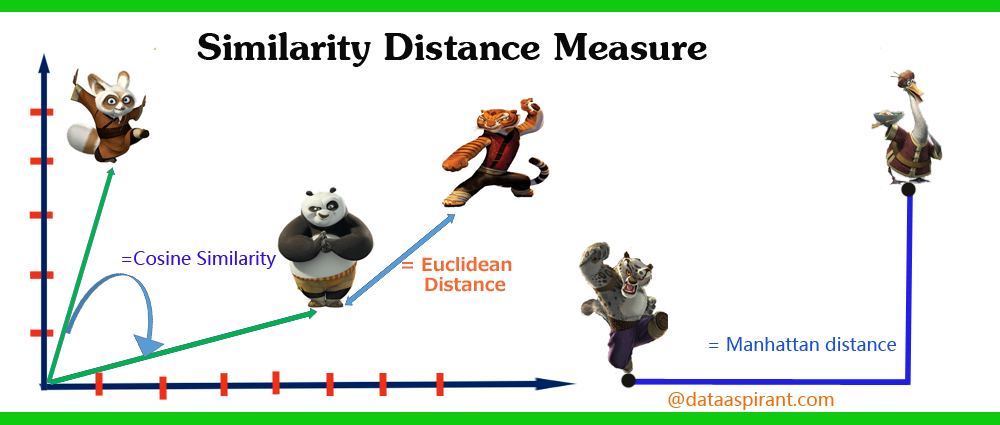

✅ 1. Cosine Similarity
Measures the cosine of the angle between two vectors (how similar their directions are).

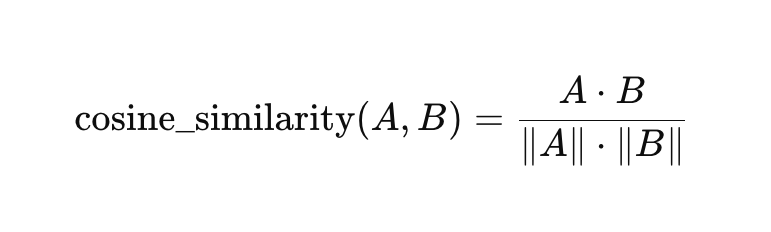



In [28]:
Product_A =  [1, 0, 1, 0, 1, 0, 0, 1, 0, 1]
Product_B = [0, 1, 1, 0, 1, 1, 0, 0, 1, 0]
Product_C = [1, 1, 0, 1, 0, 0, 1, 0, 1, 1]

| Feature Index | Feature Name (Example)     |
| ------------- | -------------------------- |
| 0             | Wireless                   |
| 1             | Bluetooth                  |
| 2             | Noise Cancelling           |
| 3             | Over-ear                   |
| 4             | Portable                   |
| 5             | Voice Assistant Compatible |
| 6             | Foldable                   |
| 7             | Water Resistant            |
| 8             | Fast Charging              |
| 9             | Long Battery Life          |


| Index | A | B | A \* B |
| ----- | - | - | ------ |
| 0     | 1 | 0 | 0      |
| 1     | 0 | 1 | 0      |
| 2     | 1 | 1 | 1      |
| 3     | 0 | 0 | 0      |
| 4     | 1 | 1 | 1      |
| 5     | 0 | 1 | 0      |
| 6     | 0 | 0 | 0      |
| 7     | 1 | 0 | 0      |
| 8     | 0 | 1 | 0      |
| 9     | 1 | 0 | 0      |


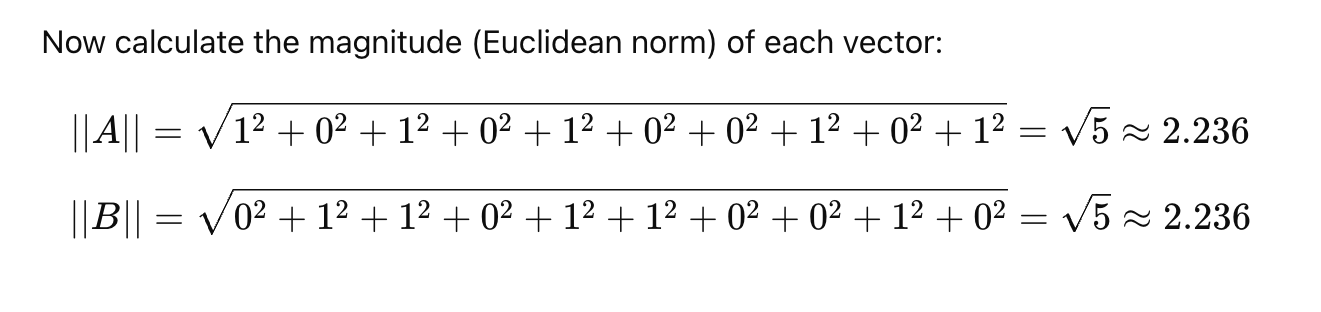


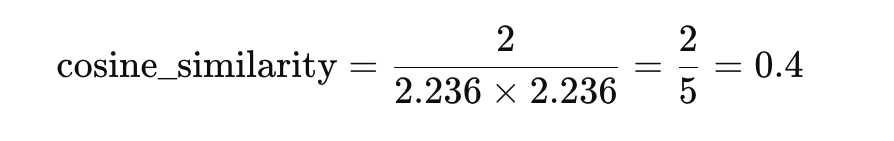

|               | Product A | Product B | Product C |
| ------------- | --------- | --------- | --------- |
| **Product A** | 1.000     | 0.400     | 0.365     |
| **Product B** | 0.400     | 1.000     | 0.365     |
| **Product C** | 0.365     | 0.365     | 1.000     |


In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer


In [30]:
import pandas as pd
df = pd.read_csv("restaurant.csv")
df.head()

,Restaurant,City,Cuisine
0,Kochi Kitchen,Kerala,"North Indian, Mughlai, Chinese"
1,Hotel Chandra,Hyderabad,"Cafe, Mexican, Italian"
2,Cafe Coffee Day Surat,Surat,"North Indian, Rajasthani"
3,Hotel KRC Palace,Tezpur,North Indian
4,Galaxy Surat,Surat,"North Indian, South Indian, Andhra, Chinese"


In [31]:
df['City'] = df['City'].apply(str.lower)
df.head()

,Restaurant,City,Cuisine
0,Kochi Kitchen,kerala,"North Indian, Mughlai, Chinese"
1,Hotel Chandra,hyderabad,"Cafe, Mexican, Italian"
2,Cafe Coffee Day Surat,surat,"North Indian, Rajasthani"
3,Hotel KRC Palace,tezpur,North Indian
4,Galaxy Surat,surat,"North Indian, South Indian, Andhra, Chinese"


In [32]:
df.columns = ['restaurant','city','cuisine']

In [33]:
df.columns = ['restaurant','city','cuisine']

In [35]:
lat_lon = pd.read_csv("India Cities LatLng.csv")
lat_lon.head()

,city,lat,lng,country,iso2,admin_name,capital,population,population_proper
0,Delhi,28.6600,77.2300,India,IN,Delhi,admin,29617000.0,16753235.0
1,Mumbai,18.9667,72.8333,India,IN,Mahārāshtra,admin,23355000.0,12478447.0
2,Kolkāta,22.5411,88.3378,India,IN,West Bengal,admin,17560000.0,4496694.0
3,Bangalore,12.9699,77.5980,India,IN,Karnātaka,admin,13707000.0,8443675.0
4,Chennai,13.0825,80.2750,India,IN,Tamil Nādu,admin,11324000.0,6727000.0


In [36]:
lat_lon['city'] = lat_lon['city'].apply(str.lower)
lat_lon.head()

,city,lat,lng,country,iso2,admin_name,capital,population,population_proper
0,delhi,28.6600,77.2300,India,IN,Delhi,admin,29617000.0,16753235.0
1,mumbai,18.9667,72.8333,India,IN,Mahārāshtra,admin,23355000.0,12478447.0
2,kolkāta,22.5411,88.3378,India,IN,West Bengal,admin,17560000.0,4496694.0
3,bangalore,12.9699,77.5980,India,IN,Karnātaka,admin,13707000.0,8443675.0
4,chennai,13.0825,80.2750,India,IN,Tamil Nādu,admin,11324000.0,6727000.0


In [37]:
lat_lon['city'].unique()

array(['delhi', 'mumbai', 'kolkāta', 'bangalore', 'chennai', 'hyderābād',
       'pune', 'ahmadābād', 'sūrat', 'lucknow', 'jaipur', 'cawnpore',
       'mirzāpur', 'nāgpur', 'ghāziābād', 'indore', 'vadodara',
       'visakhapatnam', 'bhopāl', 'chinchvad', 'patna', 'ludhiāna',
       'āgra', 'kalyān', 'madurai', 'jamshedpur', 'nashik', 'farīdābād',
       'aurangābād', 'rājkot', 'meerut', 'jabalpur', 'thāne', 'dhanbād',
       'allahābād', 'vārānasi', 'srīnagar', 'amritsar', 'alīgarh',
       'bhiwandi', 'gwalior', 'bhilai', 'hāora', 'rānchi', 'bezwāda',
       'chandīgarh', 'mysore', 'raipur', 'kota', 'bareilly', 'jodhpur',
       'coimbatore', 'dispur', 'guwāhāti', 'solāpur', 'trichinopoly',
       'hubli', 'jalandhar', 'bhubaneshwar', 'bhayandar', 'morādābād',
       'kolhāpur', 'thiruvananthapuram', 'sahāranpur', 'warangal',
       'salem', 'mālegaon', 'kochi', 'gorakhpur', 'shimoga', 'tiruppūr',
       'guntūr', 'raurkela', 'mangalore', 'nānded', 'cuttack', 'chānda',
       'dehra d

In [38]:
lat_lon = lat_lon[['city',	'lat','lng']]

In [39]:
import unicodedata
#normalzing kagaznāgār - to. - kagaznagar
def norm(word):
  return unicodedata.normalize('NFKD', word).encode('ascii', 'ignore').decode('utf-8')


In [40]:
lat_lon['city'] = lat_lon['city'].apply(norm)

In [41]:
df = pd.merge(df,lat_lon,on='city',how='left')

In [42]:
df.dropna(inplace=True)

In [43]:
df.head()

,restaurant,city,cuisine,lat,lng
1,Hotel Chandra,hyderabad,"Cafe, Mexican, Italian",17.3667,78.4667
2,Cafe Coffee Day Surat,surat,"North Indian, Rajasthani",21.1700,72.8300
4,Galaxy Surat,surat,"North Indian, South Indian, Andhra, Chinese",21.1700,72.8300
5,The Coral Tree,agra,"Pizza, Cafe, Italian",27.1800,78.0200
6,Radisson Blu Hotel,indore,"Cafe, Italian, Continental",22.7206,75.8472


In [46]:
# Step 1: Split cuisines into lists
df['cuisine_list'] = df['cuisine'].apply(lambda x: [c.strip() for c in x.split(',')])



mlb = MultiLabelBinarizer()
cuisine_encoded = pd.DataFrame(mlb.fit_transform(df['cuisine_list']), columns=mlb.classes_, index=df.index)

"""
df['cuisine_list'] contains a list of cuisines for each restaurant (e.g., ['North Indian', 'Chinese']).

MultiLabelBinarizer() is used to convert multi-label categorical data into a binary matrix (i.e., one-hot encoded format).

fit_transform() learns all unique cuisines and transforms the list into columns of 1s and 0s.

Each column represents a cuisine. A value of 1 means that restaurant serves that cuisine, 0 means it doesn’t.

The result is stored in cuisine_encoded, a new DataFrame with the same index as the original df.
"""

# Step 3: Concatenate the original DataFrame with the encoded features
df_final = pd.concat([df.drop(columns=['cuisine_list']), cuisine_encoded], axis=1)






NameError: name 'MultiLabelBinarizer' is not defined

In [ ]:
df_final

In [ ]:
df_final.drop(["cuisine","city"],axis=1,inplace=True)

In [ ]:
df_final.set_index("restaurant",inplace=True)

In [ ]:
df_final.head()

In [47]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

In [48]:
cosine_sim_matrix = cosine_similarity(df_final)


NameError: name 'df_final' is not defined

In [ ]:
cosine_sim_df = pd.DataFrame(cosine_sim_matrix, index=df_final.index, columns=df_final.index)


In [ ]:
cosine_sim_df.head()

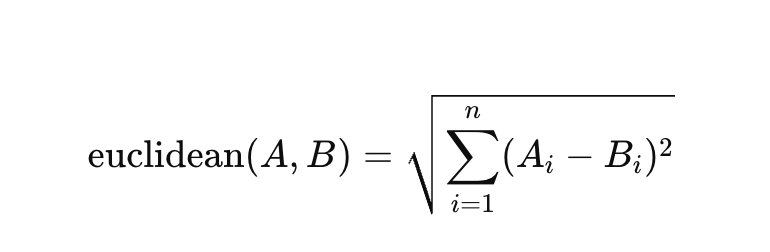

In [ ]:
#(x1, y1) (x2, y2)

#(x1-x2) ^2 + (y1-y2) ^ 2 -> euc
#(x1-x2) + (y1-y2)

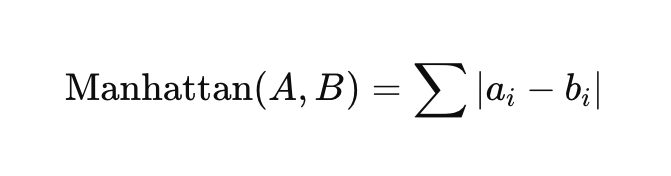

In [ ]:
cosine_sim_df.head()

In [ ]:
# Step 4: Define function to recommend top 3 similar restaurants
def recommend_restaurants(input_restaurant, sim_df, top_n=3):

    """
    Verifies whether the provided restaurant name is valid and present in the similarity matrix.

    If not found, returns a user-friendly error message.

    Fetches all similarity scores for the input_restaurant from the similarity DataFrame.

    Sorts them in descending order, so the most similar restaurants come first.

    The restaurant will always have a similarity of 1.0 with itself, so it appears first.
    """



    if input_restaurant not in sim_df.columns:
        return f"Restaurant '{input_restaurant}' not found in the data."

    # Get similarity scores for the input restaurant, sort descending
    sim_scores = sim_df[input_restaurant].sort_values(ascending=False)

    # Skip the first one (it's the same restaurant), take next top_n
    top_similar = sim_scores[1:top_n+1]#Skips the first row (index 0) since it's the restaurant compared with itself.
    return top_similar

# Step 5: Try with a user input
input_restaurant = "Galaxy Surat"
recommendations = recommend_restaurants(input_restaurant, cosine_sim_df)

print(f"Top 3 similar restaurants to '{input_restaurant}':\n")
print(recommendations)

In [ ]:
from sklearn.metrics import pairwise_distances

# Euclidean distance matrix
euclidean_dist = pairwise_distances(df_final, metric='euclidean')


euclidean_df = pd.DataFrame(euclidean_dist, index=df_final.index, columns=df_final.index)
euclidean_df.head()

In [ ]:
def recommend_restaurants_euclidean(restaurant_name, distance_matrix, top_n=3):
    if restaurant_name not in distance_matrix.index:
        return f"Restaurant '{restaurant_name}' not found in data."

    distances = distance_matrix.loc[restaurant_name].sort_values()

    # Exclude the restaurant itself (distance = 0)
    recommendations = distances[1:top_n+1]
    return recommendations

In [ ]:
recommendations = recommend_restaurants_euclidean("Galaxy Surat", euclidean_df, top_n=3)
print("Top 3 similar restaurants using Euclidean Distance:\n", recommendations)


In [49]:
from sklearn.preprocessing import MinMaxScaler

# Scale the features
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df_final)

# Create a new DataFrame with the same column names and index
df_final_scaled = pd.DataFrame(scaled_features, index=df_final.index, columns=df_final.columns)
df_final_scaled.head()

NameError: name 'df_final' is not defined

In [ ]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity



# Step 2: Compute cosine similarity
cosine_sim_matrix = cosine_similarity(df_final_scaled)

# Step 3: Convert similarity matrix to DataFrame for better readability
cosine_sim_df = pd.DataFrame(cosine_sim_matrix, index=df_final.index, columns=df_final.index)


cosine_sim_df.head()

In [ ]:
# Step 5: Try with a user input
input_restaurant = "Galaxy Surat"
recommendations = recommend_restaurants(input_restaurant, cosine_sim_df)

print(f"Top 3 similar restaurants to '{input_restaurant}':\n")
print(recommendations)

In [ ]:
from sklearn.metrics import pairwise_distances
import pandas as pd

# Manhattan distance matrix
manhattan_dist = pairwise_distances(df_final_scaled, metric='manhattan')

# Convert to DataFrame for better readability
manhattan_df = pd.DataFrame(manhattan_dist, index=df_final_scaled.index, columns=df_final_scaled.index)
manhattan_df.head()

In [ ]:
def recommend_restaurants_manhattan(restaurant_name, distance_matrix, top_n=3):
    if restaurant_name not in distance_matrix.index:
        return f"Restaurant '{restaurant_name}' not found in data."

    distances = distance_matrix.loc[restaurant_name].sort_values()

    # Exclude the restaurant itself (distance = 0)
    recommendations = distances[1:top_n+1]
    return recommendations

In [ ]:
recommendations = recommend_restaurants_manhattan("Galaxy Surat", manhattan_df, top_n=3)
print("Top 3 similar restaurants using Manhattan Distance:\n", recommendations)


| Label | Category    |
| ----- | ----------- |
| 0     | T-shirt/top |
| 1     | Trouser     |
| 2     | Pullover    |
| 3     | Dress       |
| 4     | Coat        |
| 5     | Sandal      |
| 6     | Shirt       |
| 7     | Sneaker     |
| 8     | Bag         |
| 9     | Ankle boot  |

In [7]:
# 1. Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity


In [ ]:
from keras.datasets import fashion_mnist

In [3]:
import gzip
import numpy as np
import os

def load_local_data(data_dir):
    # Mapping exact local filenames
    files = {
        'train_x': 'train-images-idx3-ubyte.gz',
        'train_y': 'train-labels-idx1-ubyte.gz',
        'test_x': 't10k-images-idx3-ubyte.gz',
        'test_y': 't10k-labels-idx1-ubyte.gz'
    }

    # Load Training Images (offset 16 for IDX3)
    with gzip.open(os.path.join(data_dir, files['train_x']), 'rb') as f:
        x_train = np.frombuffer(f.read(), np.uint8, offset=16).reshape(-1, 28, 28)

    # Load Training Labels (offset 8 for IDX1)
    with gzip.open(os.path.join(data_dir, files['train_y']), 'rb') as f:
        y_train = np.frombuffer(f.read(), np.uint8, offset=8)

    # Load Test Images
    with gzip.open(os.path.join(data_dir, files['test_x']), 'rb') as f:
        x_test_org = np.frombuffer(f.read(), np.uint8, offset=16).reshape(-1, 28, 28)

    # Load Test Labels
    with gzip.open(os.path.join(data_dir, files['test_y']), 'rb') as f:
        y_test = np.frombuffer(f.read(), np.uint8, offset=8)

    return (x_train, y_train), (x_test_org, y_test)

# Assign to your variables
(x_train, y_train), (x_test_org, y_test) = load_local_data('data')

# Verification
print("Training Data Shape:", x_train.shape) # Expected: (60000, 28, 28)
print("Test Data Shape:", x_test_org.shape)   # Expected: (10000, 28, 28)

Training Data Shape: (60000, 28, 28)
Test Data Shape: (10000, 28, 28)


In [4]:
class_labels = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

In [5]:
# Get unique categories
unique_classes = np.unique(y_train)
print("Total unique categories:", len(unique_classes))
print("Category labels:", [class_labels[i] for i in unique_classes])


Total unique categories: 10
Category labels: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


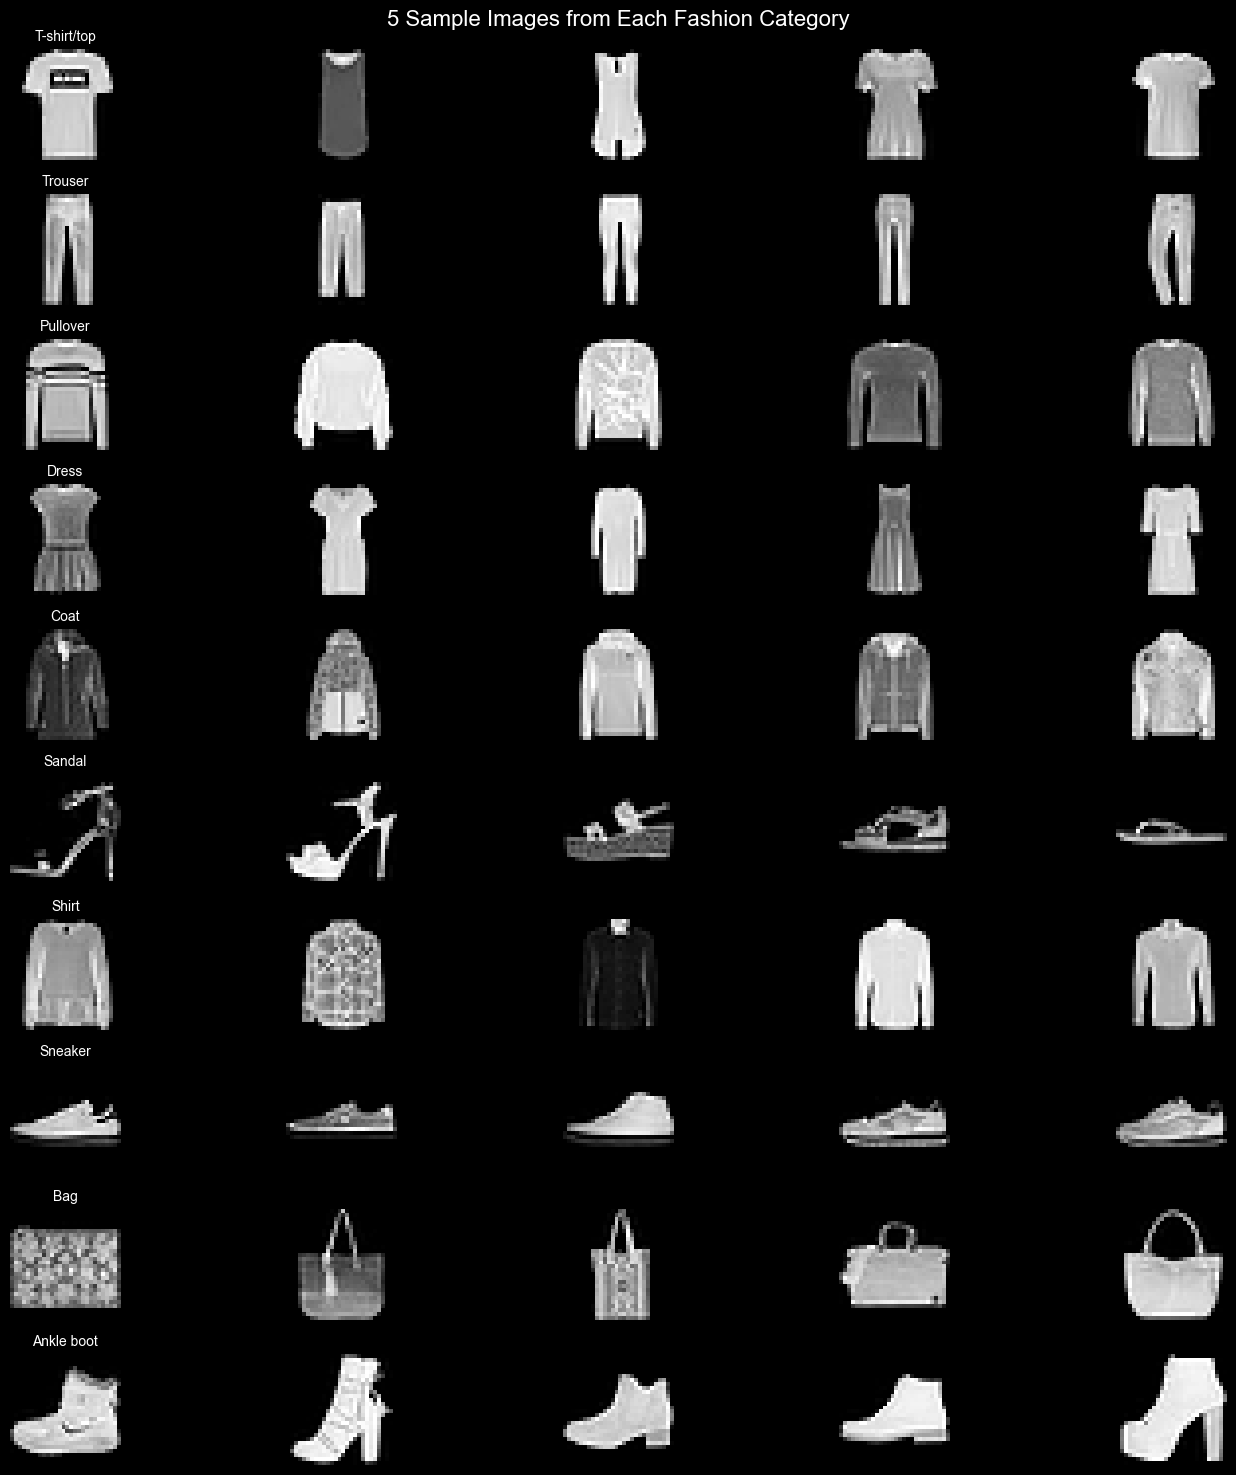

In [8]:
# Plot 5 images per category
plt.figure(figsize=(15, 15))
samples_per_class = 5

for label in unique_classes:
    idxs = np.where(y_train == label)[0][:samples_per_class]
    for i, idx in enumerate(idxs):
        plt_idx = label * samples_per_class + i + 1
        plt.subplot(10, samples_per_class, plt_idx)
        plt.imshow(x_train[idx], cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.title(class_labels[label], fontsize=10)
plt.suptitle("5 Sample Images from Each Fashion Category", fontsize=16)
plt.tight_layout()
plt.show()


In [9]:
# 3. Flatten each 28x28 image into a 784-dimensional vector
x_test = x_test_org.reshape(10000, 784)# Each image is converted into 784 pixel flatten array

print("Flattened Test Data Shape:", x_test.shape)

Flattened Test Data Shape: (10000, 784)


In [10]:
# 4. Compute cosine similarity matrix (10000 x 10000)
cos_similarity = cosine_similarity(x_test)

# Optional: Convert to DataFrame
cosine_df = pd.DataFrame(cos_similarity)

/Users/kishankunal/workspace/AppliedAI/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kishankunal/workspace/AppliedAI/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kishankunal/workspace/AppliedAI/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [13]:
# 5. Select reference image index
ref_idx = 100  # you can change this to any index 0-9999

# Get cosine similarity vector for this image
  

# Get top 10 similar images (excluding itself)
similar_images_idx = np.argsort(-image_info)[1:11]  # skip the image itself

print("Most similar image indices:", similar_images_idx)


Most similar image indices: [2172 4372 5702 7563 2793 3686 7501 1393 3364 4722]


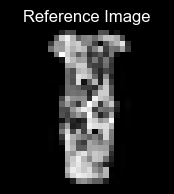

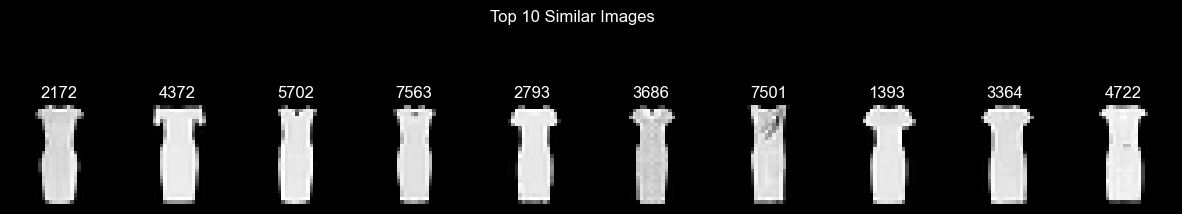

In [14]:
# 6. Display the reference image
plt.figure(figsize=(2, 2))
plt.title("Reference Image")
plt.imshow(x_test_org[ref_idx], cmap='gray')
plt.axis('off')
plt.show()

# 7. Display top 10 similar images
plt.figure(figsize=(15, 3))
for i, idx in enumerate(similar_images_idx):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_test_org[idx], cmap='gray')
    plt.title(f"{idx}")
    plt.axis('off')
plt.suptitle("Top 10 Similar Images")
plt.show()

| **Aspect**                  | **Euclidean Distance**                                                                  | **Manhattan Distance**                                                                                                         | **Cosine Similarity/Distance**                                |   |                                                                                                                                                            |
| --------------------------- | --------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------ | ------------------------------------------------------------- | - | ---------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Definition**              | Straight-line (L2 norm) distance between two points                                     | Sum of absolute differences (L1 norm)                                                                                          | Measures angle (orientation) between two vectors              |   |                                                                                                                                                            |
 **Value Range**             | \[0, ∞)                                                                                 | \[0, ∞)                                                                                                                        | $0, 2$ (as distance); $-1, 1$ as similarity                   |   |                                                                                                                                                            |
| **Scale Sensitivity**       | Sensitive to magnitude and scale                                                        | Sensitive to scale                                                                                                             | **Not sensitive** to magnitude (only direction matters)       |   |                                                                                                                                                            |
| **Best Use Case**           | Dense continuous numeric data (e.g., image pixels)                                      | Sparse or grid-like data (e.g., city block distances)                                                                          | Text similarity, high-dimensional sparse data (e.g., TF-IDF)  |   |                                                                                                                                                            |
| **Computational Cost**      | Moderate                                                                                | Low                                                                                                                            | Moderate (involves normalization and dot product)             |   |                                                                                                                                                            |
| **Interprets Orientation?** | No                                                                                      | No                                                                                                                             | Yes (angle between vectors)                                   |   |                                                                                                                                                            |
| **Interprets Magnitude?**   | Yes                                                                                     | Yes                                                                                                                            | No                                                            |   |                                                                                                                                                            |
| **Sensitive to Outliers?**  | Yes                                                                                     | Yes (less than Euclidean)                                                                                                      | No (as long as direction is preserved)                        |   |                                                                                                                                                            |
| **When to Avoid**           | When features are not normalized or have outliers                                       | When actual direction matters                                                                                                  | When vector magnitudes carry semantic meaning (e.g., ratings) |   |                                                                                                                                                            |
| **Data Requirements**       | Numeric, normalized preferred                                                           | Numeric, can work with integers                                                                                                | Vectorized (dense or sparse), non-zero preferred              |   |                                                                                                                                                            |


In [ ]:
shivank -> fruits vegies curd , ragi roti
peetha -> burger, piza , curd
debasis -> fruits, curd

In [ ]:
iphone, charger

In [ ]:
#break : 9 20 pm

## 🎯 Example Dataset (Ratings Matrix)

| User/Item | Item A | Item B | Item C | Item D |
| --------- | ------ | ------ | ------ | ------ |
| User 1    | 5      | 3      | 4      | 4      |
| User 2    | 3      | 1      | 2      | 3      |
| User 3    | 4      | 3      | 4      | 3      |
| User 4    | 3      | 3      | 1      | 5      |
| User 5    | 1      | 5      | 5      | 2      |

| Item | User 1 | User 3 |
| ---- | ------ | ------ |
| A    | 5      | 4      |
| B    | 3      | 3      |
| C    | 4      | 4      |
| D    | 4      | 3      |


Let’s understand **Collaborative Filtering** in both **User-Based** and **Item-Based** approaches using a **Correlation Coefficient (Pearson)** example.

---

## 📌 Collaborative Filtering Overview

* **User-Based Collaborative Filtering (UBCF):** Recommends items to a user based on the preferences of similar users.
* **Item-Based Collaborative Filtering (IBCF):** Recommends items similar to what the user already liked or rated highly, based on item similarity.

Both methods rely on the **Pearson Correlation Coefficient** to measure **similarity**.

---

## 🎯 Example Dataset (Ratings Matrix)

| User/Item | Item A | Item B | Item C | Item D |
| --------- | ------ | ------ | ------ | ------ |
| User 1    | 5      | 3      | 4      | 4      |
| User 2    | 3      | 1      | 2      | 3      |
| User 3    | 4      | 3      | 4      | 3      |
| User 4    | 3      | 3      | 1      | 5      |
| User 5    | 1      | 5      | 5      | 2      |

Let’s calculate Pearson Correlation step-by-step.

---

## 🔹 1. User-Based Collaborative Filtering

Suppose we want to recommend an item for **User 1** based on **similar users**.

### Step 1: Pick two users to compare (e.g., User 1 and User 3)

| Item | User 1 | User 3 |
| ---- | ------ | ------ |
| A    | 5      | 4      |
| B    | 3      | 3      |
| C    | 4      | 4      |
| D    | 4      | 3      |

### Step 2: Compute Pearson Correlation Coefficient

The formula is:

$$
r = \frac{\sum{(x_i - \bar{x})(y_i - \bar{y})}}{\sqrt{\sum{(x_i - \bar{x})^2}} \sqrt{\sum{(y_i - \bar{y})^2}}}
$$

* $x_i$: ratings of User 1
* $y_i$: ratings of User 3

#### Calculate Means:

* $\bar{x} = (5+3+4+4)/4 = 4.0$
* $\bar{y} = (4+3+4+3)/4 = 3.5$

#### Now, compute the components:

| Item | x (U1) | y (U3) | x-4.0 | y-3.5 | (x-4)(y-3.5) | (x-4)² | (y-3.5)² |
| ---- | ------ | ------ | ----- | ----- | ------------ | ------ | -------- |
| A    | 5      | 4      | 1     | 0.5   | 0.5          | 1      | 0.25     |
| B    | 3      | 3      | -1    | -0.5  | 0.5          | 1      | 0.25     |
| C    | 4      | 4      | 0     | 0.5   | 0            | 0      | 0.25     |
| D    | 4      | 3      | 0     | -0.5  | 0            | 0      | 0.25     |

$$
r = \frac{0.5 + 0.5 + 0 + 0}{\sqrt{1+1+0+0} \cdot \sqrt{0.25+0.25+0.25+0.25}} = \frac{1}{\sqrt{2} \cdot \sqrt{1}} = \frac{1}{1.414} ≈ 0.71
$$

So, similarity between User 1 and User 3 is **0.71**.

---

## 🔹 2. Item-Based Collaborative Filtering

Suppose we want to find items similar to **Item A** for a recommendation.

### Step 1: Pick two items to compare (Item A and Item C)

| User | Item A | Item C |
| ---- | ------ | ------ |
| U1   | 5      | 4      |
| U2   | 3      | 2      |
| U3   | 4      | 4      |
| U4   | 3      | 1      |
| U5   | 1      | 5      |

### Step 2: Compute Pearson Correlation Coefficient

#### Calculate Means:

* $\bar{x} = (5+3+4+3+1)/5 = 3.2$
* $\bar{y} = (4+2+4+1+5)/5 = 3.2$

#### Compute the components:

| User | x (A) | y (C) | x-3.2 | y-3.2 | (x-3.2)(y-3.2) | (x-3.2)² | (y-3.2)² |
| ---- | ----- | ----- | ----- | ----- | -------------- | -------- | -------- |
| U1   | 5     | 4     | 1.8   | 0.8   | 1.44           | 3.24     | 0.64     |
| U2   | 3     | 2     | -0.2  | -1.2  | 0.24           | 0.04     | 1.44     |
| U3   | 4     | 4     | 0.8   | 0.8   | 0.64           | 0.64     | 0.64     |
| U4   | 3     | 1     | -0.2  | -2.2  | 0.44           | 0.04     | 4.84     |
| U5   | 1     | 5     | -2.2  | 1.8   | -3.96          | 4.84     | 3.24     |

$$
r = \frac{1.44 + 0.24 + 0.64 + 0.44 - 3.96}{\sqrt{3.24 + 0.04 + 0.64 + 0.04 + 4.84} \cdot \sqrt{0.64 + 1.44 + 0.64 + 4.84 + 3.24}}
$$

$$
r = \frac{-1.2}{\sqrt{8.8} \cdot \sqrt{10.8}} = \frac{-1.2}{2.966 \cdot 3.286} ≈ \frac{-1.2}{9.75} ≈ -0.123
$$

So, similarity between Item A and C is **-0.123**, which indicates **negative correlation** — i.e., they are dissimilar.

---

## ✅ Summary

| Approach   | Compared Entities | Correlation | Meaning              |
| ---------- | ----------------- | ----------- | -------------------- |
| User-Based | User 1 & User 3   | 0.71        | Users are similar    |
| Item-Based | Item A & Item C   | -0.123      | Items are dissimilar |

---

Would you like me to show how to **implement this in Python** using NumPy or Pandas?


In [ ]:
import pandas as pd

# Paths to the four MovieLens-100k files you mounted on Drive
base_path  = "/"
ratings_all = pd.read_csv(base_path + "u.data",
                          sep="\t",
                          names=["user_id", "movie_id", "rating", "timestamp"])

ratings_train = pd.read_csv(base_path + "ua.base",
                            sep="\t",
                            names=ratings_all.columns)

ratings_test  = pd.read_csv(base_path + "ua.test",
                            sep="\t",
                            names=ratings_all.columns)

users  = pd.read_csv(base_path + "u.user",
                     sep="|",
                     names=["user_id", "age", "sex", "occupation", "zip_code"])

movies = pd.read_csv(base_path + "u.item",
                     sep="|",
                     names=["movie_id", "title", "release_date", "video_release_date",
                            "imdb_url", "unknown", "action", "adventure", "animation",
                            "children", "comedy", "crime", "documentary", "drama",
                            "fantasy", "film_noir", "horror", "musical", "mystery",
                            "romance", "sci_fi", "thriller", "war", "western"],
                     encoding="latin-1")


In [ ]:
ratings_train.head()

,user_id,movie_id,rating,timestamp
0,1,1,5,874965758
1,1,2,3,876893171
2,1,3,4,878542960
3,1,4,3,876893119
4,1,5,3,889751712


In [ ]:
ratings_test.head()

,user_id,movie_id,rating,timestamp
0,1,20,4,887431883
1,1,33,4,878542699
2,1,61,4,878542420
3,1,117,3,874965739
4,1,155,2,878542201


In [ ]:
users.head()

,user_id,age,sex,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [ ]:
movies.head()

,movie_id,title,release_date,video_release_date,imdb_url,unknown,action,adventure,animation,children,...,fantasy,film_noir,horror,musical,mystery,romance,sci_fi,thriller,war,western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
!pip install -q lightfm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.4/316.4 kB 17.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from lightfm import LightFM
from lightfm.data import Dataset
import numpy as np

In [ ]:
'''
Dataset() is from the LightFM or Spotlight library (both used for recommendation systems).

dataset.fit(...) is like registering all users and all movies in your dataset.

Think of it like assigning each user and movie a unique number (index).
For example:

User "u101" → index 0

Movie "m23" → index 0
And so on.
'''
# Step 2.1: Initialize Dataset
dataset = Dataset()
dataset.fit(
    users=ratings_train['user_id'].unique(),
    items=ratings_train['movie_id'].unique()
)

#take tupple and turn into sparse matrix
# Step 2.2: Build interactions with float ratings
'''
This matrix says:
"User A gave a rating of 4.0 to Movie B"
"User C gave a rating of 2.5 to Movie D", etc.'''
interactions, weights = dataset.build_interactions(
    [(row['user_id'], row['movie_id'], float(row['rating']))
     for _, row in ratings_train.iterrows()]
)

'''
weights.tocoo().data gives you all non-zero ratings in the matrix (since it's sparse, many entries are empty).

np.unique(...) prints the unique rating values (e.g., [1.0, 2.5, 3.0, 4.0, 5.0]).'''
# non -zero from sparse matrix
print("Unique interaction weights:", np.unique(weights.tocoo().data))

Unique interaction weights: [1. 2. 3. 4. 5.]


In [ ]:
from scipy.sparse import coo_matrix

# Convert to COO if not already
interactions = interactions.tocoo()
weights = weights.tocoo()
import pandas as pd

interactions_df = pd.DataFrame({
    'user_id': interactions.row,
    'movie_id': interactions.col,
    'interaction': interactions.data
})

weights_df = pd.DataFrame({
    'user_id': weights.row,
    'movie_id': weights.col,
    'weight': weights.data
})



In [ ]:
interactions_df

,user_id,movie_id,interaction
0,0,0,1
1,0,1,1
2,0,2,1
3,0,3,1
4,0,4,1
...,...,...,...
90565,942,1034,1
90566,942,1063,1
90567,942,1173,1
90568,942,1211,1


In [ ]:
weights_df

,user_id,movie_id,weight
0,0,0,5.0
1,0,1,3.0
2,0,2,4.0
3,0,3,3.0
4,0,4,3.0
...,...,...,...
90565,942,1034,2.0
90566,942,1063,4.0
90567,942,1173,3.0
90568,942,1211,3.0


In [ ]:
visual_df = interactions_df.merge(weights_df, on=['user_id', 'movie_id'])
visual_df = visual_df.sort_values(by=['user_id', 'movie_id']).reset_index(drop=True)

print(visual_df.head(10))

   user_id  movie_id  interaction  weight
0        0         0            1     5.0
1        0         1            1     3.0
2        0         2            1     4.0
3        0         3            1     3.0
4        0         4            1     3.0
5        0         5            1     5.0
6        0         6            1     4.0
7        0         7            1     1.0
8        0         8            1     5.0
9        0         9            1     3.0


In [ ]:
'''
Great — you're now getting ready to analyze or visualize the interaction data efficiently.
This step converts your matrices into a format that makes it faster to work with by rows (i.e., by user).
ou have a big attendance register (1000s of rows and columns), mostly empty.

COO format is like: “Here’s a list of marked entries.”

CSR format is like: “Here’s everything student #2 did — instantly.”
interactions_csr[0].toarray()
Output:
array([[4., 0., 3.]])
This means:

User 0 rated movie 0 with 4

User 0 did not rate movie 1 → 0

User 0 rated movie 2 with 3
'''
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import numpy as np

# Ensure both are in CSR format for easy slicing
interactions_csr = interactions.tocsr()
weights_csr = weights.tocsr()

In [ ]:
# Take a small slice: first 10 users x first 10 movies
slice_size = 10
interactions_slice = interactions_csr[:slice_size, :slice_size].toarray()
weights_slice = weights_csr[:slice_size, :slice_size].toarray()

print("Interactions (binary):")
print(interactions_slice)

print("\nWeights (ratings):")
print(weights_slice)

Interactions (binary):
[[1 1 1 1 1 1 1 1 1 1]
 [1 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 1 1 1 0]
 [0 0 0 1 0 0 1 1 1 1]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [1 0 0 1 0 0 0 0 1 0]]

Weights (ratings):
[[5. 3. 4. 3. 3. 5. 4. 1. 5. 3.]
 [4. 0. 0. 0. 0. 0. 0. 0. 0. 2.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [4. 0. 0. 0. 0. 0. 2. 4. 4. 0.]
 [0. 0. 0. 5. 0. 0. 5. 5. 5. 4.]
 [0. 0. 0. 0. 0. 0. 3. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 4. 0. 0. 0.]
 [4. 0. 0. 4. 0. 0. 0. 0. 4. 0.]]


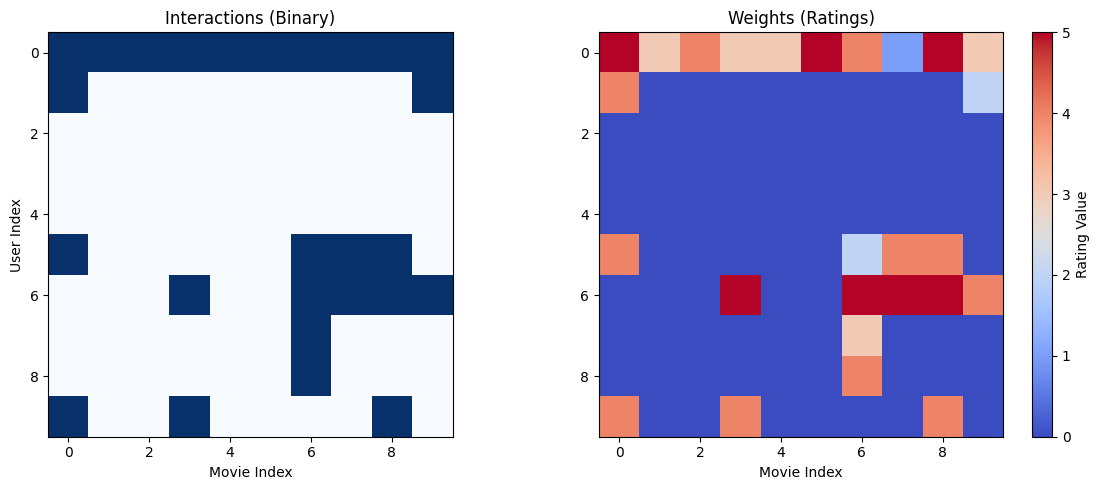

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Interactions
axes[0].imshow(interactions_slice, cmap='Blues', interpolation='none')
axes[0].set_title('Interactions (Binary)')
axes[0].set_xlabel('Movie Index')
axes[0].set_ylabel('User Index')

# Plot Weights
im = axes[1].imshow(weights_slice, cmap='coolwarm', interpolation='none')
axes[1].set_title('Weights (Ratings)')
axes[1].set_xlabel('Movie Index')

# Add colorbar
plt.colorbar(im, ax=axes[1], label='Rating Value')

plt.tight_layout()
plt.show()

In [ ]:
from lightfm import LightFM
# STEP 3: Train the LightFM model using WARP loss
model = LightFM(no_components=32, loss='warp', random_state=42)

# Train using both interactions and weights
model.fit(interactions, sample_weight=weights, epochs=20, num_threads=2)
print("Model trained!")

Model trained!


In [ ]:
def recommend_movie_titles_for_user(model, dataset, user_id, movies_df, N=5):
    # Extract LightFM internal mappings
    '''
    user_id_map: maps external user_id → internal user_id

    item_id_map: maps external movie_id → internal movie_id
    '''
    user_id_map, _, item_id_map, _ = dataset.mapping()

    # Check if user_id exists in mapping
    if user_id not in user_id_map:
        raise ValueError(f"User ID {user_id} not found in the dataset mapping.")

    internal_user_id = user_id_map[user_id]
    num_items = len(item_id_map)

    # Predict scores for all items for the user
    scores = model.predict(user_ids=internal_user_id, item_ids=np.arange(num_items))

    # Get top N item indices (internal IDs)
    top_indices = np.argsort(-scores)[:N]  # negative for descending sort

    # Reverse mapping: internal → external movie_id
    '''
    Creates a reverse mapping: internal movie ID → external movie ID.

    Uses this to translate LightFM’s internal movie indices back to the original movie IDs
    you have in your movie dataset.
    '''
    inv_item_id_map = {v: k for k, v in item_id_map.items()}
    recommended_movie_ids = [inv_item_id_map[i] for i in top_indices]

    # Get movie titles
    recommended_movies = movies_df[movies_df['movie_id'].isin(recommended_movie_ids)]
    recommended_movies = recommended_movies.set_index('movie_id').loc[recommended_movie_ids].reset_index()

    return recommended_movies


In [ ]:
user_id_to_predict = 3  # External user_id (e.g., from dataset)
top_recommendations = recommend_movie_titles_for_user(model, dataset, user_id=user_id_to_predict, movies_df=movies, N=5)

print(f"Top 5 recommended movies for User {user_id_to_predict}:")
top_recommendations

Top 5 recommended movies for User 3:


,movie_id,title,release_date,video_release_date,imdb_url,unknown,action,adventure,animation,children,...,fantasy,film_noir,horror,musical,mystery,romance,sci_fi,thriller,war,western
0,258,Contact (1997),11-Jul-1997,NaN,http://us.imdb.com/Title?Contact+(1997/I),0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,300,Air Force One (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Air+Force+One...,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,288,Scream (1996),20-Dec-1996,NaN,http://us.imdb.com/M/title-exact?Scream%20(1996),0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
3,302,L.A. Confidential (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
4,327,Cop Land (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Cop+Land+(1997),0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
def get_user_history(user_id, ratings_df, movies_df, min_rating=4.0):
    """Get all movies a user has rated >= min_rating"""
    user_history = ratings_df[(ratings_df['user_id'] == user_id) & (ratings_df['rating'] >= min_rating)]
    return pd.merge(user_history, movies_df, on='movie_id')


In [ ]:
user_3_history = get_user_history(3, ratings_train, movies)
print(f"\nUser 3 Highly Rated Movies:\n{user_3_history[['movie_id', 'title', 'rating']]}")



User 3 Highly Rated Movies:
    movie_id                                              title  rating
0        181                          Return of the Jedi (1983)       4
1        260                               Event Horizon (1997)       4
2        318                            Schindler's List (1993)       4
3        320  Paradise Lost: The Child Murders at Robin Hood...       5
4        321                                      Mother (1996)       5
5        327                                    Cop Land (1997)       4
6        329                          Desperate Measures (1998)       4
7        340                               Boogie Nights (1997)       5
8        342                Man Who Knew Too Little, The (1997)       4
9        344                                Apostle, The (1997)       4
10       346                                Jackie Brown (1997)       5
11       347                                 Wag the Dog (1997)       5
12       348                       

In [ ]:
recommended_3 = recommend_movie_titles_for_user(model, dataset, user_id=3, movies_df=movies, N=5)
print(f"\nTop 5 Recommended Movies for User 3:\n{recommended_3[['movie_id', 'title']]}")



Top 5 Recommended Movies for User 3:
   movie_id                     title
0       258            Contact (1997)
1       300      Air Force One (1997)
2       288             Scream (1996)
3       302  L.A. Confidential (1997)
4       327           Cop Land (1997)


In [ ]:
model

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Item embedding matrix (num_items x embedding_dim)
item_embeddings = model.item_embeddings


In [ ]:
item_embeddings

array([[ 0.9072999 , -0.29125237,  0.24899998, ...,  0.17496715,
         0.53351635,  0.6795645 ],
       [-0.12743056,  0.58120507,  0.11763223, ...,  0.33895466,
        -0.15238553,  0.4418629 ],
       [ 0.31727722, -0.22609454, -0.01170931, ...,  0.05973583,
         0.47669277,  0.11725441],
       ...,
       [-0.2366847 ,  0.22028258, -0.59273976, ..., -0.266325  ,
         0.3507859 , -0.08052494],
       [-0.2652147 , -0.30728802, -0.03840943, ..., -0.0462055 ,
        -0.2348663 , -0.44866204],
       [-0.2684636 ,  0.09428065, -0.5750265 , ..., -0.12843172,
        -0.04480812, -0.28875613]], dtype=float32)

In [ ]:
cos_sim_matrix = cosine_similarity(item_embeddings)


In [ ]:
item_id_map = dataset.mapping()[2]  # movie_id to LightFM index
reverse_item_map = {v: k for k, v in item_id_map.items()}  # index to movie_id
def get_top_k_similar_items(movie_id, k=5):
    if movie_id not in item_id_map:
        print(f"Movie ID {movie_id} not found in item_id_map.")
        return []

    idx = item_id_map[movie_id]
    sim_scores = cos_sim_matrix[idx]

    # Exclude the item itself and get top-k indices
    similar_idx = np.argsort(-sim_scores)  # descending
    similar_idx = similar_idx[similar_idx != idx][:k]  # remove self

    similar_movie_ids = [reverse_item_map[i] for i in similar_idx]
    similar_scores = [sim_scores[i] for i in similar_idx]

    return list(zip(similar_movie_ids, similar_scores))



In [ ]:
print("Top 3 similar to movie 583:")
print(get_top_k_similar_items(583, k=3))

print("\nTop 3 similar to movie 884:")
print(get_top_k_similar_items(884, k=3))

Top 3 similar to movie 583:
[(943, 0.6257556), (1109, 0.6198911), (1209, 0.5744669)]

Top 3 similar to movie 884:
[(883, 0.8021825), (830, 0.77252483), (341, 0.75915444)]


In [ ]:
import pandas as pd
df = pd.read_csv("groceries-groceries.csv")
df.head()

,Item(s),Item 1,Item 2,Item 3,Item 4,Item 5,Item 6,Item 7,Item 8,Item 9,...,Item 23,Item 24,Item 25,Item 26,Item 27,Item 28,Item 29,Item 30,Item 31,Item 32
0,4,citrus fruit,semi-finished bread,margarine,ready soups,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,pip fruit,yogurt,cream cheese,meat spreads,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,other vegetables,whole milk,condensed milk,long life bakery product,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
!pip -q install mlxtend --upgrade


In [ ]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules


In [ ]:
# 2.1  Read the file exactly as you showed (33 columns: Item(s) + 32 items)
df_raw = pd.read_csv("groceries-groceries.csv")

# 2.2  Quick sanity check
df_raw.head()

,Item(s),Item 1,Item 2,Item 3,Item 4,Item 5,Item 6,Item 7,Item 8,Item 9,...,Item 23,Item 24,Item 25,Item 26,Item 27,Item 28,Item 29,Item 30,Item 31,Item 32
0,4,citrus fruit,semi-finished bread,margarine,ready soups,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,pip fruit,yogurt,cream cheese,meat spreads,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,other vegetables,whole milk,condensed milk,long life bakery product,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
transactions = []

for idx, row in df_raw.iterrows():
    # Row[1:] skips the "Item(s)" count column
    basket = [item for item in row[1:] if pd.notna(item)]
    transactions.append(basket)

print("Example basket 0:", transactions[0])
print("Total baskets  :", len(transactions))

Example basket 0: ['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups']
Total baskets  : 9835


In [ ]:
print(f"{len(transactions):,} baskets loaded "
      f"with {len(set(sum(transactions, []))):,} unique products")

9,835 baskets loaded with 169 unique products


In [ ]:
basket_sizes = [len(t) for t in transactions]
pd.Series(basket_sizes).describe()

,0
count,9835.000000
mean,4.409456
std,3.589385
min,1.000000
25%,2.000000
50%,3.000000
75%,6.000000
max,32.000000


In [ ]:
te = TransactionEncoder()
item_matrix = te.fit_transform(transactions)
df_items = pd.DataFrame(item_matrix, columns=te.columns_)
df_items.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
t = [[a,b],[n,m,b],[r,t]]

a b n m b r t
T T F F F F F
F F T t T

In [ ]:
df_items.sum()

,0
Instant food products,79
UHT-milk,329
abrasive cleaner,35
artif. sweetener,32
baby cosmetics,6
...,...
white bread,414
white wine,187
whole milk,2513
yogurt,1372


In [ ]:
top_items = df_items.sum().sort_values(ascending=False).head(15) / len(df_items)
print(top_items.round(3))

whole milk          0.256
other vegetables    0.193
rolls/buns          0.184
soda                0.174
yogurt              0.140
bottled water       0.111
root vegetables     0.109
tropical fruit      0.105
shopping bags       0.099
sausage             0.094
pastry              0.089
citrus fruit        0.083
bottled beer        0.081
newspapers          0.080
canned beer         0.078
dtype: float64


In [ ]:
df_basket = pd.DataFrame(item_matrix, columns=te.columns_)
df_basket.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
2 Million
#phone #kitchenware

In [ ]:
Ml engineers ->
AI engineer ->
Data scientists